# ITAG7105 – Data Mining
## Descriptive, Predictive, and Text Analytics for Airline Customer Reviews
**Module Code:** ITAG7105 | **Submission Deadline:** 23rd April 2026

---
### GenAI Usage Declaration
Claude (Anthropic) was used to assist with structuring the analysis pipeline and suggesting code patterns. All analytical interpretations, model selection rationale, hyperparameter choices, and critical discussion are the student's own work. All AI-generated outputs were reviewed, validated, and adapted before inclusion.

---

## 0. Dependencies & Setup

In [1]:
"""
ITAG7105 – Airline Customer Review Analytics
Dependencies: pandas, numpy, matplotlib, seaborn, scikit-learn, scipy
Python >= 3.9 required
Random seed fixed at 42 for full reproducibility.
"""

import warnings
warnings.filterwarnings('ignore')

# Standard library
import re
import string
import collections
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from scipy import stats

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Colour palette
YES_COLOR = '#2196F3'
NO_COLOR  = '#F44336'
PALETTE   = [YES_COLOR, NO_COLOR]

print("✅ Setup complete. Random seed:", RANDOM_SEED)

✅ Setup complete. Random seed: 42


---
## Section 3 – Data Pre-Processing

### 3.1 Load Raw Data

In [3]:
def load_raw_data(filepath: str) -> pd.DataFrame:
    """
    Load the airline review dataset from an Excel file.

    Parameters
    ----------
    filepath : str
        Path to the .xlsx file.

    Returns
    -------
    pd.DataFrame
        Raw DataFrame with all original columns.
    """
    df = pd.read_excel(filepath)
    print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


# ── Load ─────────────────────────────────────────────────────────────────────
DATA_PATH = 'MGT0000_ITAG7105_new_dataset_final.xlsx'
raw_df = load_raw_data(DATA_PATH)
print("\nColumn names:", list(raw_df.columns))
raw_df.head(3)

Loaded 6,178 rows × 21 columns

Column names: ['ID', 'Airline Name', 'Overall_Rating', 'Review Title', 'Country', 'Review Date', 'Verified', 'Review', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Ground Service', 'Wifi & Connectivity', 'Value For Money', 'Recommended', 'Aircraft']


,ID,Airline Name,Overall_Rating,Review Title,Country,Review Date,Verified,Review,Type Of Traveller,Seat Type,...,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,0,AB Aviation,8,"""pretty decent airline""",Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,...,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,1,AB Aviation,3,"""Not a good airline""",United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,...,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,2,AB Aviation,3,"""flight was fortunately short""",United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,...,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120


### 3.2 Pre-Cleaning Quality Audit

=== PRE-CLEANING QUALITY AUDIT ===
                          dtype  missing  missing_%  unique
ID                       object        0        0.0    6178
Airline Name             object        0        0.0     440
Overall_Rating           object        0        0.0      18
Review Title             object        0        0.0    3910
Country                  object        0        0.0     144
Review Date              object        0        0.0    1689
Verified                   bool        0        0.0       1
Review                   object        0        0.0    4112
Type Of Traveller        object        2        0.0       4
Seat Type                object        0        0.0       4
Route                    object        9        0.1    3413
Date Flown               object        2        0.0      95
Seat Comfort            float64      580        9.4       5
Cabin Staff Service     float64      638       10.3       5
Food & Beverages        float64     2217       35.9       5
Infli

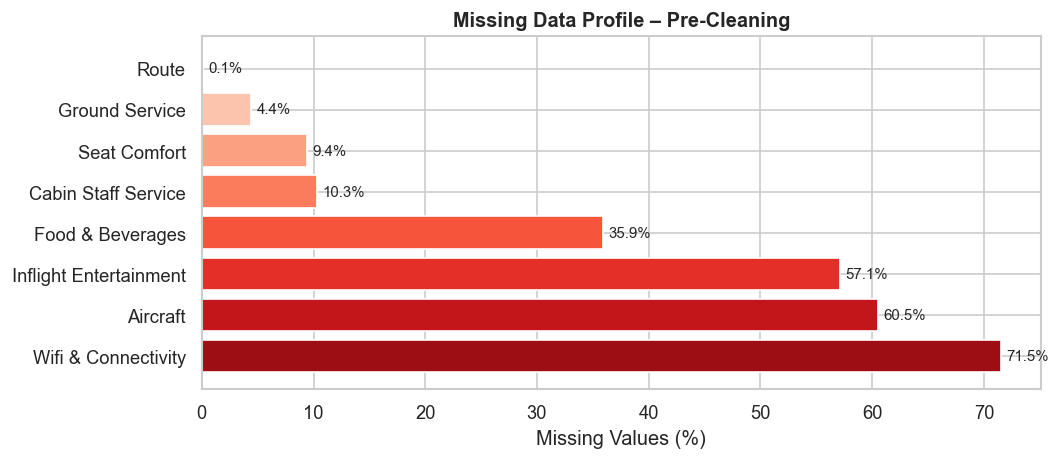

Figure 1: Missing data profile saved.


In [4]:
def audit_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Produce a summary of missing values, data types, and unique counts.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Audit table.
    """
    audit = pd.DataFrame({
        'dtype':   df.dtypes,
        'missing': df.isnull().sum(),
        'missing_%': (df.isnull().mean() * 100).round(1),
        'unique':  df.nunique()
    })
    return audit


pre_audit = audit_data_quality(raw_df)
print("=== PRE-CLEANING QUALITY AUDIT ===")
print(pre_audit.to_string())

# ── Visualise missingness ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
miss_pct = pre_audit['missing_%'].sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
bars = ax.barh(miss_pct.index, miss_pct.values, color=sns.color_palette('Reds_r', len(miss_pct)))
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Data Profile – Pre-Cleaning', fontweight='bold')
for bar, val in zip(bars, miss_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_01_missing_data_precleaning.png', bbox_inches='tight')
plt.show()
print("Figure 1: Missing data profile saved.")

### 3.3 Numerical Data Cleaning

In [5]:
def clean_overall_rating(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce Overall_Rating to numeric, replacing non-numeric tokens
    ('n', empty strings, etc.) with NaN.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        DataFrame with Overall_Rating as float64.
    """
    df = df.copy()
    df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
    invalid_count = df['Overall_Rating'].isnull().sum()
    print(f"Overall_Rating: {invalid_count} non-numeric values coerced to NaN")
    return df


def impute_numerical_features(
    df: pd.DataFrame,
    rating_cols: list,
    strategy: str = 'median'
) -> pd.DataFrame:
    """
    Impute missing values in rating columns.

    Strategy chosen: median imputation, which is robust to the skew
    typically present in Likert-scale ratings.  Alternative (mean) is
    demonstrated for comparison.

    Parameters
    ----------
    df : pd.DataFrame
    rating_cols : list
        Column names to impute.
    strategy : str
        'median' (selected) or 'mean' (alternative).

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()
    for col in rating_cols:
        if col in df.columns:
            fill_val = df[col].median() if strategy == 'median' else df[col].mean()
            missing_before = df[col].isnull().sum()
            df[col] = df[col].fillna(fill_val)
            print(f"  {col}: filled {missing_before} NaNs with {strategy} = {fill_val:.2f}")
    return df


def encode_binary_target(df: pd.DataFrame, col: str = 'Recommended') -> pd.DataFrame:
    """
    Map 'yes'/'no' target to 1/0.

    Parameters
    ----------
    df : pd.DataFrame
    col : str
        Name of the target column.

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()
    mapping = {'yes': 1, 'no': 0}
    df[col] = df[col].str.strip().str.lower().map(mapping)
    unmapped = df[col].isnull().sum()
    if unmapped > 0:
        print(f"WARNING: {unmapped} unmapped values in '{col}'")
    else:
        print(f"Target '{col}': mapped successfully (1=yes, 0=no)")
    return df


# ── Numerical rating columns ──────────────────────────────────────────────────
RATING_COLS = [
    'Overall_Rating', 'Seat Comfort', 'Cabin Staff Service',
    'Food & Beverages', 'Inflight Entertainment', 'Ground Service',
    'Wifi & Connectivity', 'Value For Money'
]

# ── Pipeline ──────────────────────────────────────────────────────────────────
print("--- Step 1: Fix Overall_Rating ---")
df = clean_overall_rating(raw_df)

print("\n--- Step 2: Median imputation (selected strategy) ---")
df = impute_numerical_features(df, RATING_COLS, strategy='median')

print("\n--- Step 3: Encode target ---")
df = encode_binary_target(df, 'Recommended')

print("\nTarget distribution:")
print(df['Recommended'].value_counts())
print(f"Class imbalance ratio: {df['Recommended'].value_counts()[0] / df['Recommended'].value_counts()[1]:.2f}:1")

--- Step 1: Fix Overall_Rating ---
Overall_Rating: 74 non-numeric values coerced to NaN

--- Step 2: Median imputation (selected strategy) ---
  Overall_Rating: filled 74 NaNs with median = 3.00
  Seat Comfort: filled 580 NaNs with median = 2.00
  Cabin Staff Service: filled 638 NaNs with median = 3.00
  Food & Beverages: filled 2217 NaNs with median = 2.00
  Inflight Entertainment: filled 3530 NaNs with median = 1.00
  Ground Service: filled 273 NaNs with median = 1.00
  Wifi & Connectivity: filled 4416 NaNs with median = 1.00
  Value For Money: filled 1 NaNs with median = 2.00

--- Step 3: Encode target ---
Target 'Recommended': mapped successfully (1=yes, 0=no)

Target distribution:
Recommended
0    4279
1    1899
Name: count, dtype: int64
Class imbalance ratio: 2.25:1


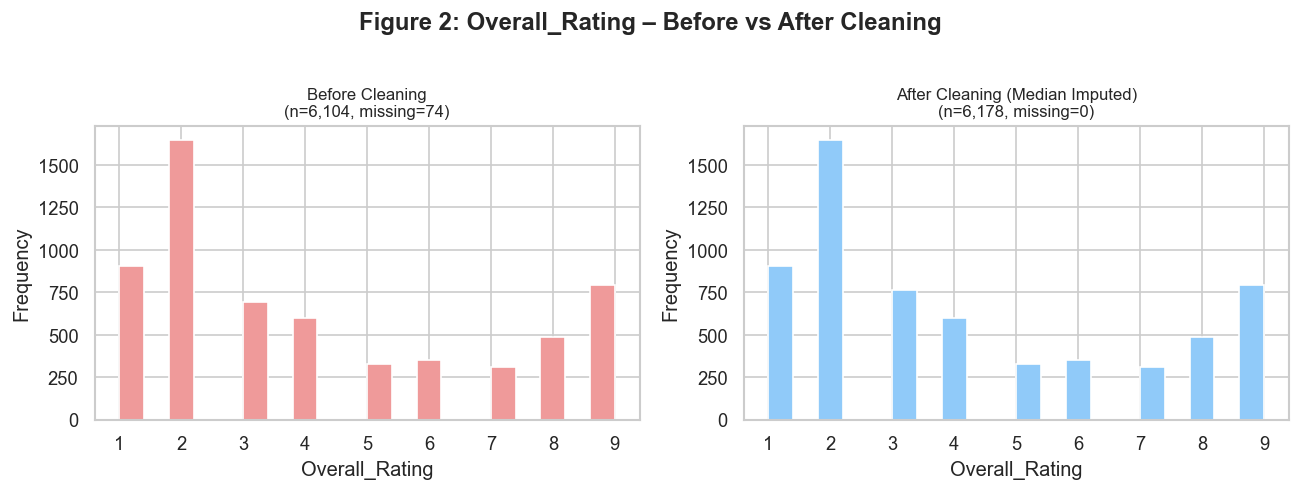

=== POST-CLEANING AUDIT ===
                        missing  missing_%
ID                            0        0.0
Airline Name                  0        0.0
Overall_Rating                0        0.0
Review Title                  0        0.0
Country                       0        0.0
Review Date                   0        0.0
Verified                      0        0.0
Review                        0        0.0
Type Of Traveller             2        0.0
Seat Type                     0        0.0
Route                         9        0.1
Date Flown                    2        0.0
Seat Comfort                  0        0.0
Cabin Staff Service           0        0.0
Food & Beverages              0        0.0
Inflight Entertainment        0        0.0
Ground Service                0        0.0
Wifi & Connectivity           0        0.0
Value For Money               0        0.0
Recommended                   0        0.0
Aircraft                   3738       60.5


In [6]:
# ── Pre vs Post cleaning comparison ──────────────────────────────────────────
def plot_pre_post_comparison(raw: pd.DataFrame, cleaned: pd.DataFrame,
                             col: str, title: str):
    """
    Plot side-by-side histogram comparing raw and cleaned distributions.

    Parameters
    ----------
    raw : pd.DataFrame
    cleaned : pd.DataFrame
    col : str
    title : str
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, data, label, color in zip(
        axes,
        [pd.to_numeric(raw[col], errors='coerce'), cleaned[col]],
        ['Before Cleaning', 'After Cleaning (Median Imputed)'],
        ['#EF9A9A', '#90CAF9']
    ):
        ax.hist(data.dropna(), bins=20, color=color, edgecolor='white')
        ax.set_title(f'{label}\n(n={data.notna().sum():,}, missing={data.isna().sum():,})',
                     fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
    fig.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_02_pre_post_{col.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


plot_pre_post_comparison(raw_df, df, 'Overall_Rating',
                         'Figure 2: Overall_Rating – Before vs After Cleaning')

post_audit = audit_data_quality(df)
print("=== POST-CLEANING AUDIT ===")
print(post_audit[['missing', 'missing_%']].to_string())

### 3.4 Text Pre-Processing Pipeline

In [7]:
# ── Airline-specific stop words (common but uninformative in this domain) ────
DOMAIN_STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'is', 'was', 'were', 'are', 'be', 'been', 'being', 'have', 'has',
    'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may',
    'might', 'shall', 'with', 'from', 'by', 'as', 'this', 'that', 'it',
    'its', 'we', 'i', 'my', 'our', 'they', 'their', 'he', 'she', 'his',
    'her', 'you', 'your', 'very', 'so', 'also', 'just', 'not', 'no', 'up',
    'out', 'there', 'then', 'than', 'when', 'which', 'who', 'what', 'if',
    'into', 'all', 'about', 'trip', 'verified', 'flight', 'airline',
    'aircraft', 'seat', 'class', 'economy'
}


def preprocess_review_text(text: str) -> str:
    """
    Context-specific text preprocessing pipeline for airline reviews.

    Steps:
    1. Remove verification badge (✅Trip Verified|)
    2. Lowercase
    3. Remove URLs and email addresses
    4. Remove punctuation (preserve apostrophes for contractions – see note)
    5. Remove digits
    6. Tokenise on whitespace
    7. Remove domain-specific stop words
    8. Remove tokens shorter than 3 characters

    NOTE ON LIMITATIONS: Removing punctuation collapses negation markers
    ("not good" → "good"). Sarcasm and irony (e.g., "great for a budget
    airline") cannot be detected by bag-of-words approaches. These are
    acknowledged biases inherent in this pipeline.

    Parameters
    ----------
    text : str

    Returns
    -------
    str
        Preprocessed, space-joined tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    # Step 1: Remove verification badge
    text = re.sub(r'✅?Trip Verified\|?', '', text)
    text = re.sub(r'Not Verified\|?', '', text)

    # Step 2: Lowercase
    text = text.lower()

    # Step 3: Remove URLs and emails
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', '', text)

    # Step 4: Remove punctuation (preserve hyphens for compound words)
    text = re.sub(r"[^\w\s-]", ' ', text)

    # Step 5: Remove digits
    text = re.sub(r'\d+', '', text)

    # Step 6-8: Tokenise, filter stop words and short tokens
    tokens = [
        tok.strip('-')
        for tok in text.split()
        if tok.strip('-') not in DOMAIN_STOPWORDS and len(tok.strip('-')) >= 3
    ]

    return ' '.join(tokens)


# ── Apply to corpus ──────────────────────────────────────────────────────────
df['review_clean'] = df['Review'].apply(preprocess_review_text)

# Quality check
empty_reviews = (df['review_clean'] == '').sum()
print(f"Empty reviews after preprocessing: {empty_reviews}")
print("\nSample cleaned review:")
print(df['review_clean'].iloc[1][:200])

Empty reviews after preprocessing: 0

Sample cleaned review:
moroni anjouan small ticket advised turn hrs confusion small airport directed office aviation still closed opened hrs told put back hrs tried contact true phone number local guide informed either pres


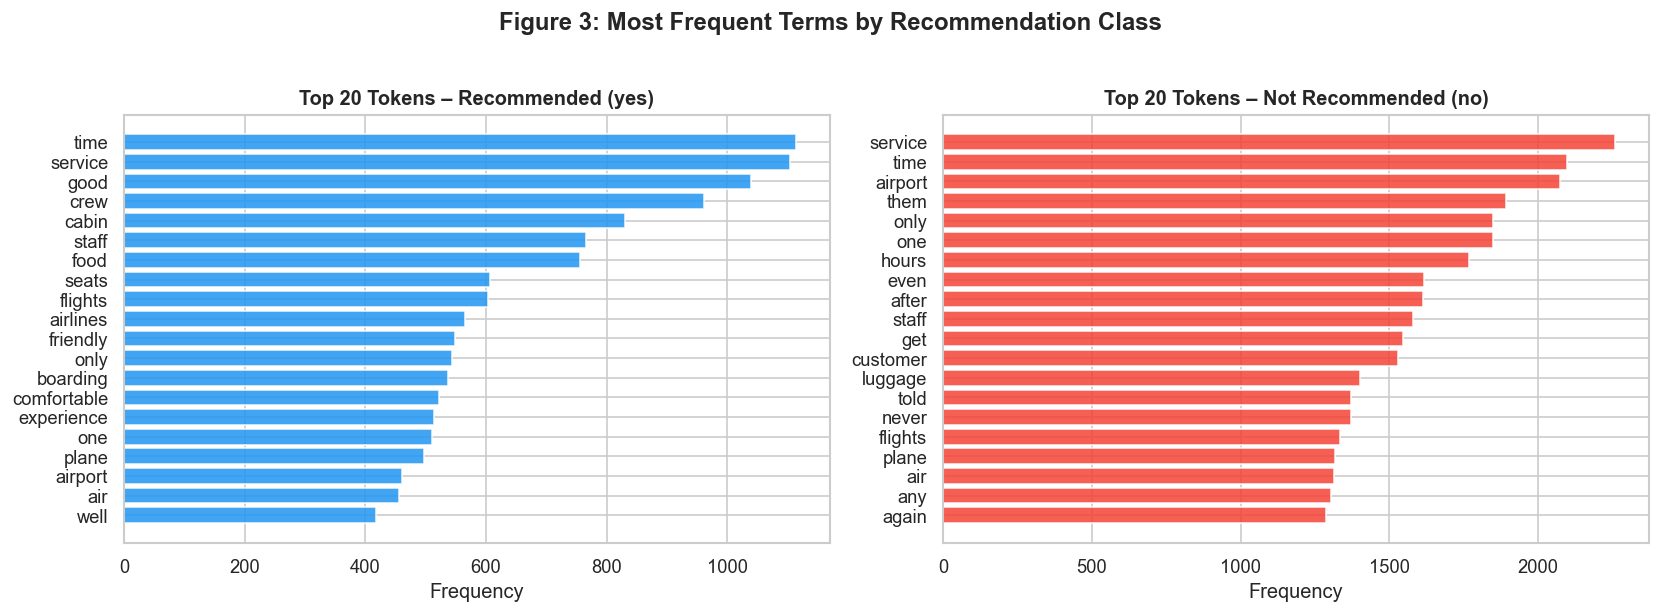

Figure 3 saved.


In [8]:
# ── Exploratory text analysis: top tokens by recommendation class ─────────────
def get_top_tokens(corpus: pd.Series, n: int = 20) -> pd.Series:
    """
    Count token frequencies across a corpus.

    Parameters
    ----------
    corpus : pd.Series
        Series of preprocessed text strings.
    n : int
        Number of top tokens to return.

    Returns
    -------
    pd.Series
        Token counts, descending.
    """
    all_tokens = ' '.join(corpus).split()
    counts = collections.Counter(all_tokens)
    return pd.Series(dict(counts.most_common(n)))


yes_tokens = get_top_tokens(df.loc[df['Recommended'] == 1, 'review_clean'])
no_tokens  = get_top_tokens(df.loc[df['Recommended'] == 0, 'review_clean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tokens, label, color in zip(
    axes,
    [yes_tokens, no_tokens],
    ['Recommended (yes)', 'Not Recommended (no)'],
    [YES_COLOR, NO_COLOR]
):
    ax.barh(tokens.index[::-1], tokens.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 20 Tokens – {label}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Figure 3: Most Frequent Terms by Recommendation Class', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_top_tokens_by_class.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

---
## Section 4.a – Descriptive & Predictive Analytics (Numerical Features)

### 4.a.1 Descriptive Statistics

In [9]:
def compute_descriptive_stats(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Compute descriptive statistics for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
    cols : list
        Numerical column names.

    Returns
    -------
    pd.DataFrame
        Summary statistics table.
    """
    stats_df = df[cols].describe().T
    stats_df['skewness'] = df[cols].skew()
    stats_df['kurtosis'] = df[cols].kurtosis()
    stats_df['median']   = df[cols].median()
    return stats_df.round(3)


desc_stats = compute_descriptive_stats(df, RATING_COLS)
print("=== DESCRIPTIVE STATISTICS ===")
print(desc_stats.to_string())

=== DESCRIPTIVE STATISTICS ===
                         count   mean    std  min  25%  50%  75%  max  skewness  kurtosis  median
Overall_Rating          6178.0  4.176  2.770  1.0  2.0  3.0  7.0  9.0     0.595    -1.111     3.0
Seat Comfort            6178.0  2.533  1.410  1.0  1.0  2.0  4.0  5.0     0.438    -1.144     2.0
Cabin Staff Service     6178.0  2.851  1.539  1.0  1.0  3.0  4.0  5.0     0.114    -1.425     3.0
Food & Beverages        6178.0  2.357  1.230  1.0  2.0  2.0  3.0  5.0     0.906    -0.166     2.0
Inflight Entertainment  6178.0  1.514  1.110  1.0  1.0  1.0  1.0  5.0     2.069     2.974     1.0
Ground Service          6178.0  2.310  1.608  1.0  1.0  1.0  4.0  5.0     0.670    -1.246     1.0
Wifi & Connectivity     6178.0  1.247  0.846  1.0  1.0  1.0  1.0  5.0     3.556    11.618     1.0
Value For Money         6178.0  2.353  1.587  1.0  1.0  2.0  4.0  5.0     0.661    -1.200     2.0


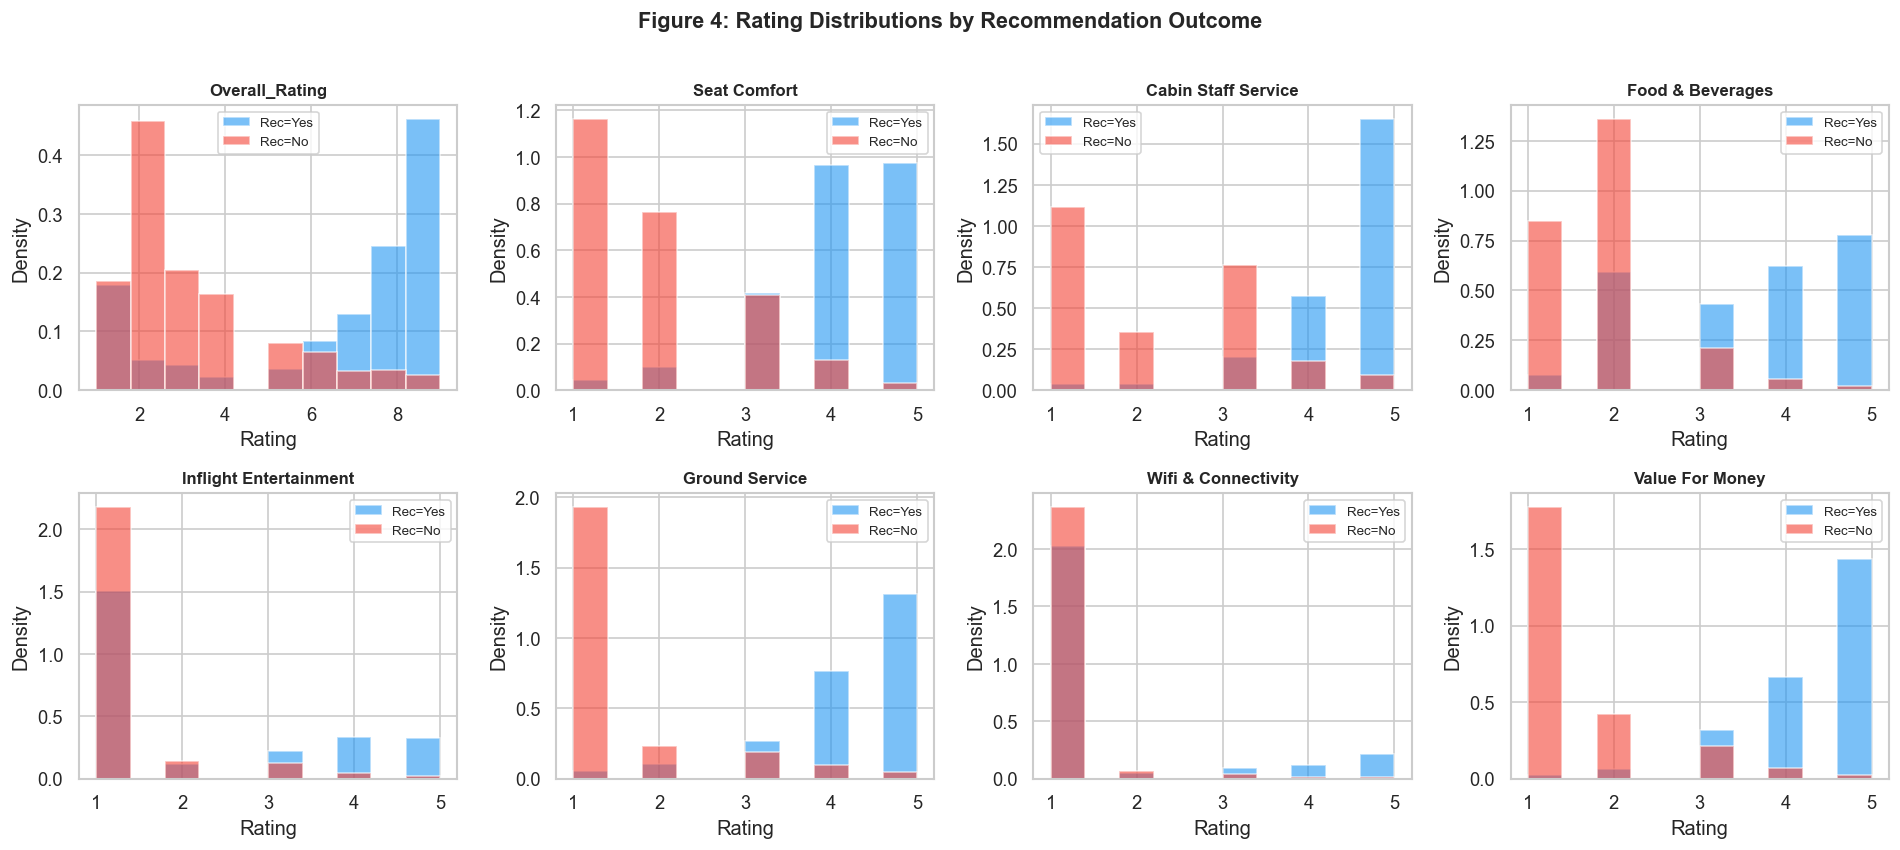

Figure 4 saved.


In [10]:
# ── Figure 4: Distribution of all numerical ratings ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, col in enumerate(RATING_COLS):
    ax = axes[idx]
    for rec, color, label in [(1, YES_COLOR, 'Yes'), (0, NO_COLOR, 'No')]:
        subset = df.loc[df['Recommended'] == rec, col]
        ax.hist(subset, bins=10, alpha=0.6, color=color, label=f'Rec={label}',
                density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Figure 4: Rating Distributions by Recommendation Outcome', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_rating_distributions.png', bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

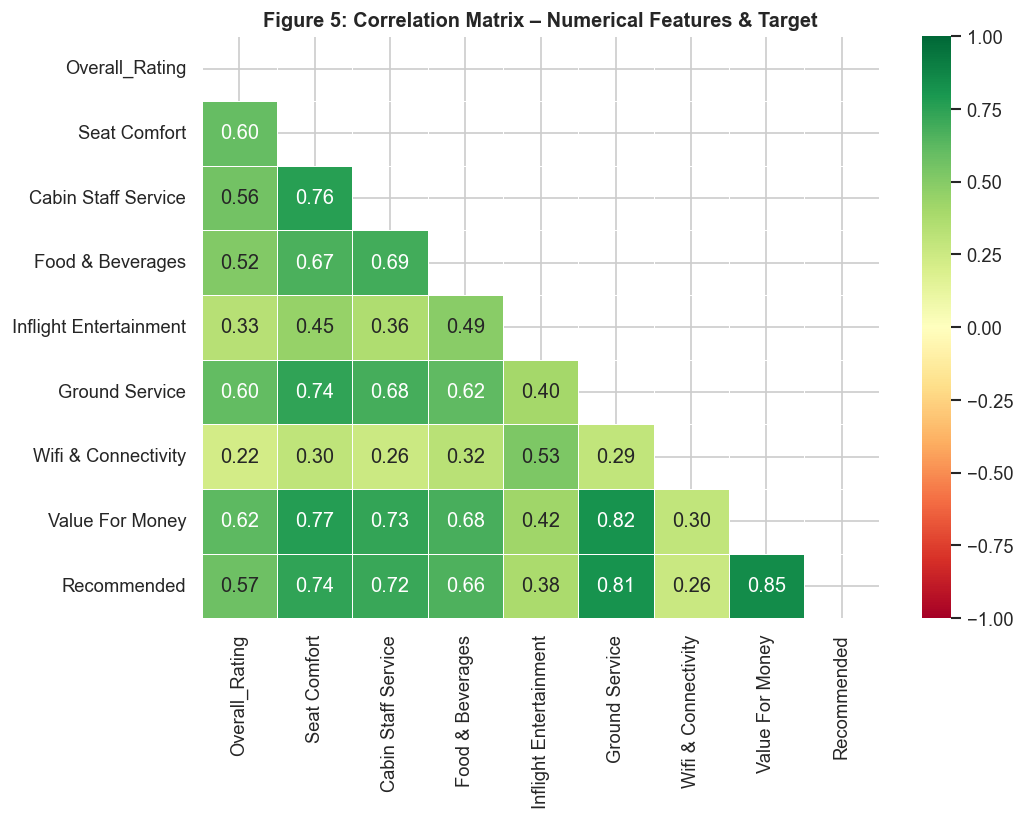

Figure 5 saved.

Correlations with Recommended:
Value For Money           0.846919
Ground Service            0.812706
Seat Comfort              0.735881
Cabin Staff Service       0.716166
Food & Beverages          0.659082
Overall_Rating            0.572868
Inflight Entertainment    0.377002
Wifi & Connectivity       0.259098
Name: Recommended, dtype: float64


In [11]:
# ── Figure 5: Correlation heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[RATING_COLS + ['Recommended']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, ax=ax, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white'
)
ax.set_title('Figure 5: Correlation Matrix – Numerical Features & Target', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

# Report top correlations with target
target_corr = corr_matrix['Recommended'].drop('Recommended').sort_values(ascending=False)
print("\nCorrelations with Recommended:")
print(target_corr)

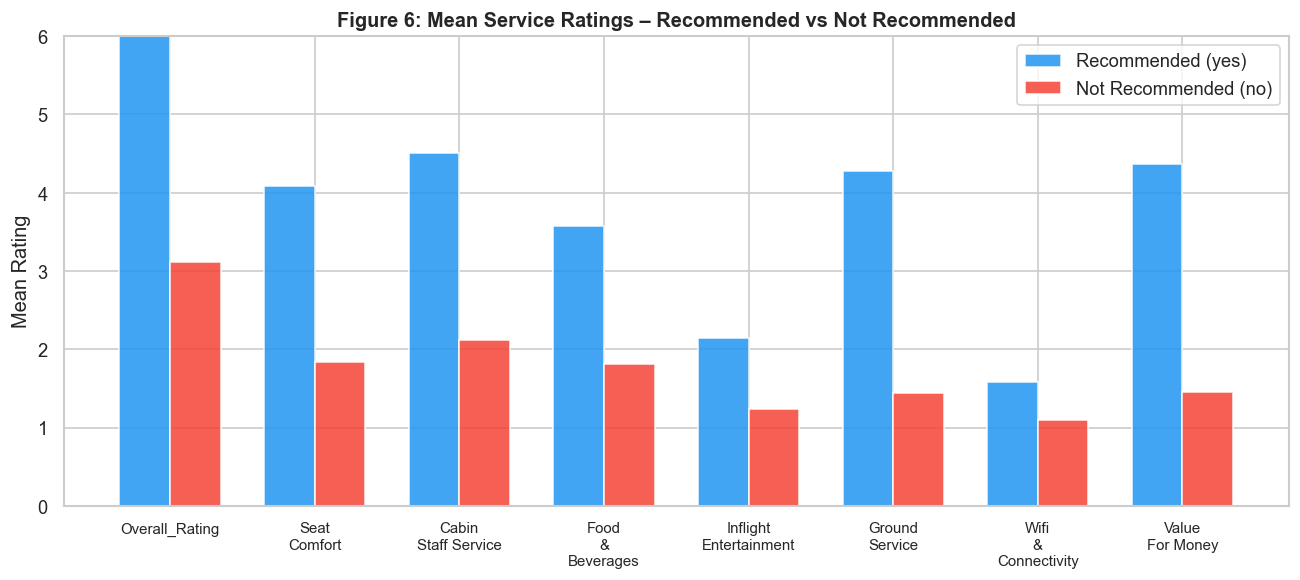

Figure 6 saved.


In [12]:
# ── Figure 6: Comparative bar chart – Mean ratings by Recommendation class ────
mean_ratings = df.groupby('Recommended')[RATING_COLS].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(RATING_COLS))
width = 0.35

bars1 = ax.bar(x - width/2, mean_ratings.loc[1], width, label='Recommended (yes)',
               color=YES_COLOR, alpha=0.85)
bars2 = ax.bar(x + width/2, mean_ratings.loc[0], width, label='Not Recommended (no)',
               color=NO_COLOR, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [c.replace(' & ', '\n& ').replace(' ', '\n', 1) for c in RATING_COLS],
    fontsize=9
)
ax.set_ylabel('Mean Rating')
ax.set_title('Figure 6: Mean Service Ratings – Recommended vs Not Recommended',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 6)
plt.tight_layout()
plt.savefig('fig_06_mean_ratings_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

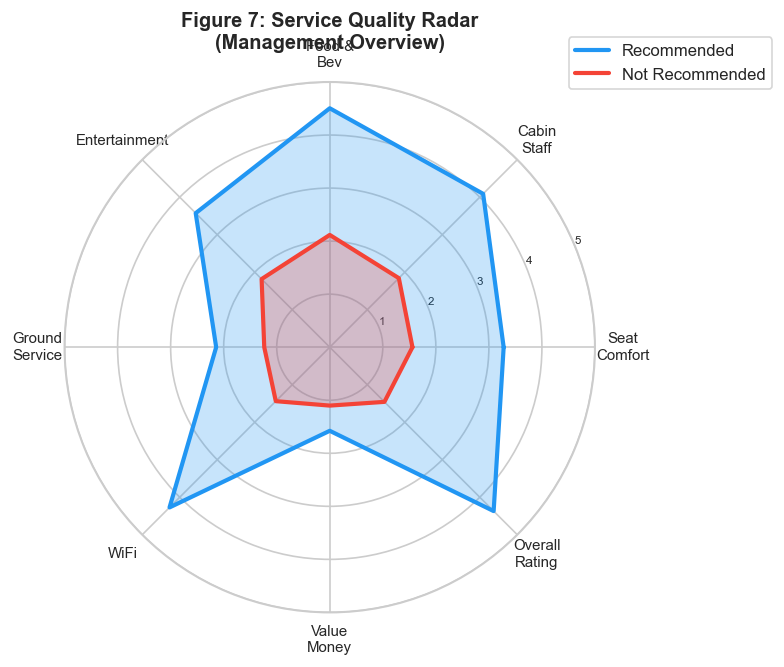

Figure 7 saved.


In [13]:
# ── Figure 7: MANAGEMENT DASHBOARD – Radar/Spider chart (non-technical) ───────
categories = ['Seat\nComfort', 'Cabin\nStaff', 'Food &\nBev', 'Entertainment',
              'Ground\nService', 'WiFi', 'Value\nMoney', 'Overall\nRating']
cols_radar  = RATING_COLS  # same order

# Scale Overall_Rating to 0-5 (it's on 0-10)
def scale_rating(df, col, from_max=10, to_max=5):
    return df[col] / from_max * to_max if col == 'Overall_Rating' else df[col]

yes_vals = [scale_rating(df[df['Recommended']==1], c).mean() for c in cols_radar]
no_vals  = [scale_rating(df[df['Recommended']==0], c).mean() for c in cols_radar]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
yes_vals_r = yes_vals + [yes_vals[0]]
no_vals_r  = no_vals  + [no_vals[0]]
angles_r   = angles   + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
ax.plot(angles_r, yes_vals_r, color=YES_COLOR, linewidth=2.5, label='Recommended')
ax.fill(angles_r, yes_vals_r, color=YES_COLOR, alpha=0.25)
ax.plot(angles_r, no_vals_r, color=NO_COLOR, linewidth=2.5, label='Not Recommended')
ax.fill(angles_r, no_vals_r, color=NO_COLOR, alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.yaxis.set_tick_params(labelsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.set_title('Figure 7: Service Quality Radar\n(Management Overview)',
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig_07_radar_management_dashboard.png', bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

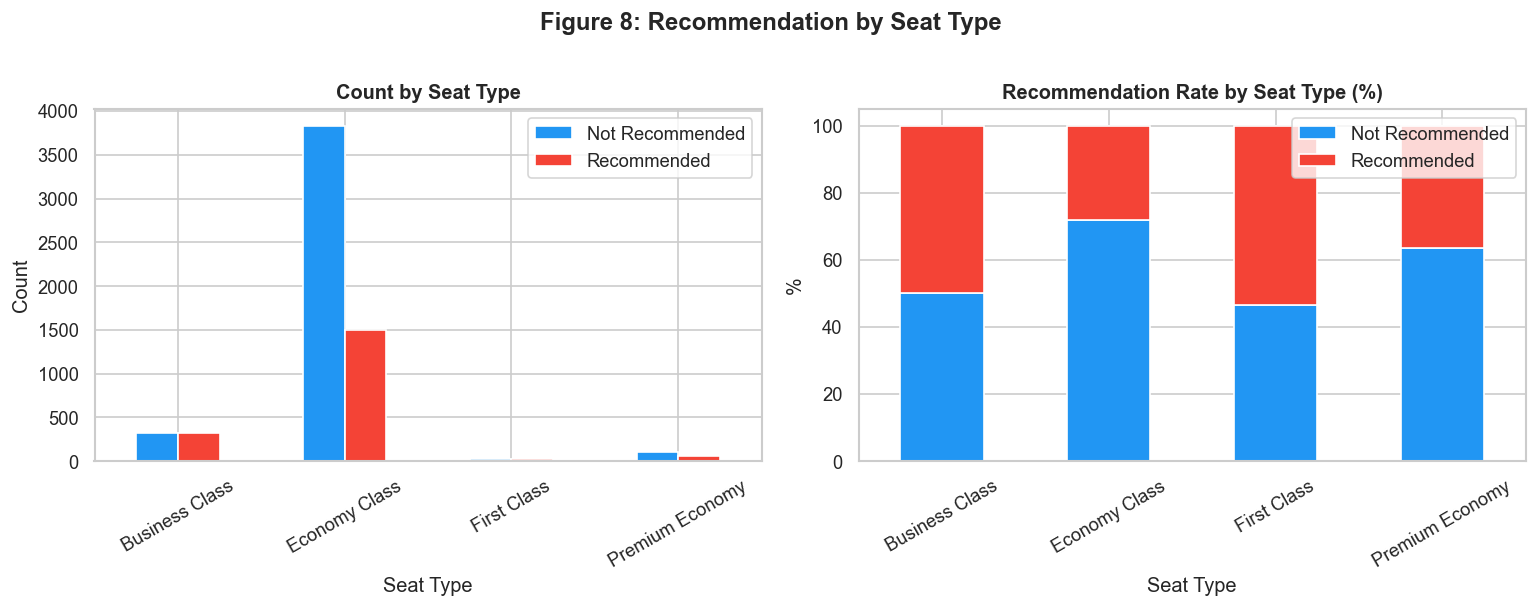

Figure 8 saved.


In [14]:
# ── Figure 8: Seat Type × Recommendation (comparative) ───────────────────────
seat_rec = df.groupby(['Seat Type', 'Recommended']).size().unstack(fill_value=0)
seat_rec_pct = seat_rec.div(seat_rec.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seat_rec.plot(kind='bar', ax=axes[0], color=PALETTE, rot=30, legend=True)
axes[0].set_title('Count by Seat Type', fontweight='bold')
axes[0].set_xlabel('Seat Type')
axes[0].set_ylabel('Count')
axes[0].legend(['Not Recommended', 'Recommended'])

seat_rec_pct.plot(kind='bar', ax=axes[1], color=PALETTE, rot=30, stacked=True)
axes[1].set_title('Recommendation Rate by Seat Type (%)', fontweight='bold')
axes[1].set_xlabel('Seat Type')
axes[1].set_ylabel('%')
axes[1].legend(['Not Recommended', 'Recommended'])

plt.suptitle('Figure 8: Recommendation by Seat Type', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_08_seattype_recommendation.png', bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

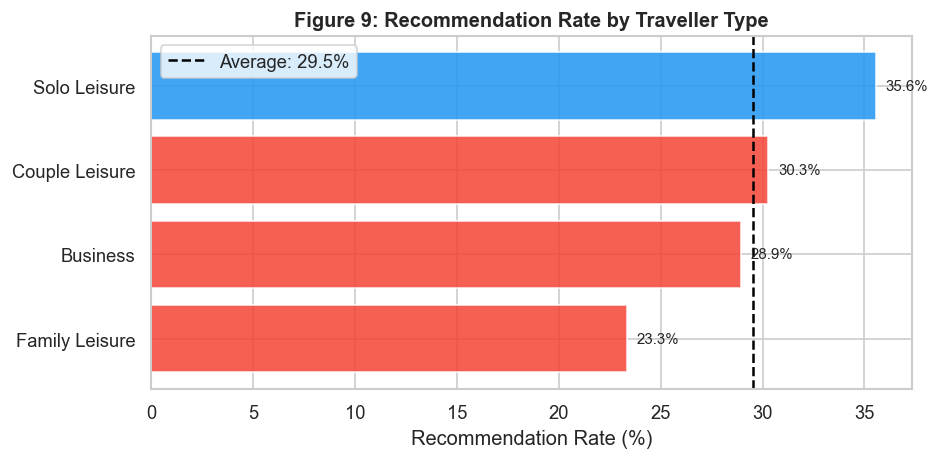

Figure 9 saved.


In [15]:
# ── Figure 9: Traveller type recommendation rate ──────────────────────────────
trav_rec = df.groupby('Type Of Traveller')['Recommended'].mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(8, 4))
colors = [YES_COLOR if v > 33 else NO_COLOR for v in trav_rec.values]
bars = ax.barh(trav_rec.index, trav_rec.values, color=colors, alpha=0.85)
ax.axvline(trav_rec.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Average: {trav_rec.mean():.1f}%')
ax.set_xlabel('Recommendation Rate (%)')
ax.set_title('Figure 9: Recommendation Rate by Traveller Type', fontweight='bold')
ax.legend()
for bar, val in zip(bars, trav_rec.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_09_traveller_recommendation_rate.png', bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

### 4.a.2 Predictive Analytics – Numerical Features

In [16]:
def prepare_numerical_features(df: pd.DataFrame, feature_cols: list,
                                target_col: str = 'Recommended'):
    """
    Extract numerical feature matrix and target vector.

    Parameters
    ----------
    df : pd.DataFrame
    feature_cols : list
    target_col : str

    Returns
    -------
    X : pd.DataFrame
    y : pd.Series
    """
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    # Encode categorical columns
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    # Final imputation safeguard
    X = X.fillna(X.median(numeric_only=True))
    return X, y


def train_and_evaluate_model(model, X_train, X_test, y_train, y_test,
                              model_name: str) -> dict:
    """
    Fit a model, predict on test set, and return performance metrics.

    Parameters
    ----------
    model : sklearn estimator
    X_train, X_test : array-like
    y_train, y_test : array-like
    model_name : str

    Returns
    -------
    dict
        Accuracy, F1, AUC, and classification report.
    """
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"\n{'='*55}")
    print(f" {model_name}")
    print(f"{'='*55}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    if auc:
        print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Rec.', 'Recommended']))

    return {
        'model': model, 'name': model_name,
        'acc': acc, 'f1': f1, 'auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }


# ── Feature set ───────────────────────────────────────────────────────────────
NUM_FEATURES = RATING_COLS + ['Seat Type', 'Type Of Traveller', 'Verified']

X_num, y = prepare_numerical_features(df, NUM_FEATURES)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_num, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set: {X_train_n.shape[0]:,} | Test set: {X_test_n.shape[0]:,}")
print(f"Class balance – Train: {y_train_n.mean():.3f} | Test: {y_test_n.mean():.3f}")

Training set: 4,942 | Test set: 1,236
Class balance – Train: 0.307 | Test: 0.307


In [17]:
# ── Model 1: Random Forest ────────────────────────────────────────────────────
# Rationale: RF handles mixed-type data well, is robust to overfitting via
# bagging, provides feature importances, and performs well on imbalanced classes
# with class_weight='balanced' (Breiman, 2001; Liaw & Wiener, 2002).

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1
)
rf_gs.fit(X_train_n, y_train_n)
print("RF Best params:", rf_gs.best_params_)

rf_best = rf_gs.best_estimator_
results_rf_num = train_and_evaluate_model(rf_best, X_train_n, X_test_n,
                                           y_train_n, y_test_n,
                                           'Random Forest (Numerical)')

RF Best params: {'max_depth': 10, 'n_estimators': 200}

 Random Forest (Numerical)
Accuracy : 0.9636
F1-Score : 0.9416
ROC-AUC  : 0.9889

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.98      0.97      0.97       856
 Recommended       0.93      0.96      0.94       380

    accuracy                           0.96      1236
   macro avg       0.95      0.96      0.96      1236
weighted avg       0.96      0.96      0.96      1236



In [18]:
# ── Model 2: Gradient Boosting ────────────────────────────────────────────────
# Rationale: GBM sequentially corrects errors of prior trees, producing strong
# predictors. Captures non-linear interactions. GBM has strong theoretical and
# empirical backing (Friedman, 2001; Chen & Guestrin, 2016).

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    param_grid_gb, cv=5, scoring='f1', n_jobs=-1
)
gb_gs.fit(X_train_n, y_train_n)
print("GB Best params:", gb_gs.best_params_)

gb_best = gb_gs.best_estimator_
results_gb_num = train_and_evaluate_model(gb_best, X_train_n, X_test_n,
                                           y_train_n, y_test_n,
                                           'Gradient Boosting (Numerical)')

GB Best params: {'learning_rate': 0.05, 'n_estimators': 200}

 Gradient Boosting (Numerical)
Accuracy : 0.9539
F1-Score : 0.9245
ROC-AUC  : 0.9859

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.96      0.97      0.97       856
 Recommended       0.93      0.92      0.92       380

    accuracy                           0.95      1236
   macro avg       0.95      0.94      0.95      1236
weighted avg       0.95      0.95      0.95      1236



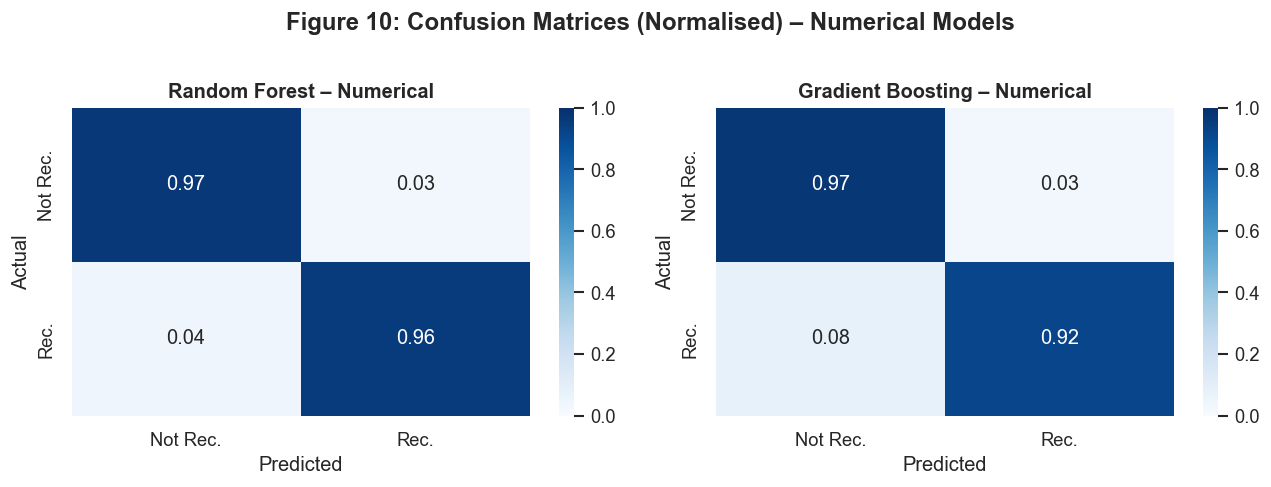

Figure 10 saved.


In [19]:
# ── Figure 10: Confusion Matrices ─────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name: str, ax, cmap='Blues'):
    """
    Plot a normalised confusion matrix.

    Parameters
    ----------
    y_true, y_pred : array-like
    model_name : str
    ax : matplotlib Axes
    cmap : str
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                xticklabels=['Not Rec.', 'Rec.'],
                yticklabels=['Not Rec.', 'Rec.'],
                vmin=0, vmax=1)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_test_n, results_rf_num['y_pred'],
                      'Random Forest – Numerical', axes[0])
plot_confusion_matrix(y_test_n, results_gb_num['y_pred'],
                      'Gradient Boosting – Numerical', axes[1])
plt.suptitle('Figure 10: Confusion Matrices (Normalised) – Numerical Models',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_10_confusion_matrices_num.png', bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

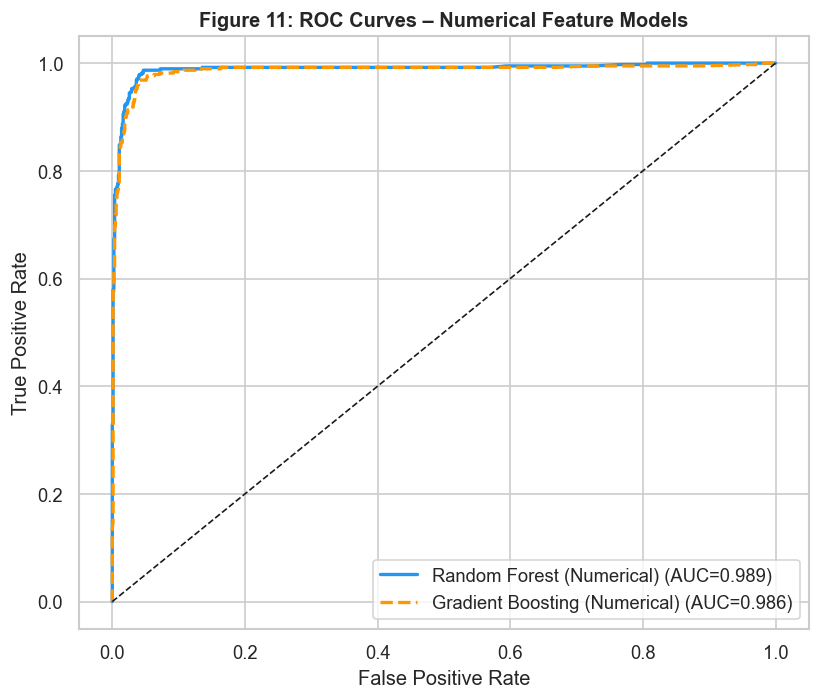

Figure 11 saved.


In [20]:
# ── Figure 11: ROC Curves ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for result, color, ls in [
    (results_rf_num, YES_COLOR, '-'),
    (results_gb_num, '#FF9800', '--')
]:
    fpr, tpr, _ = roc_curve(y_test_n, result['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2, ls=ls,
            label=f"{result['name']} (AUC={result['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 11: ROC Curves – Numerical Feature Models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_11_roc_curves_num.png', bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

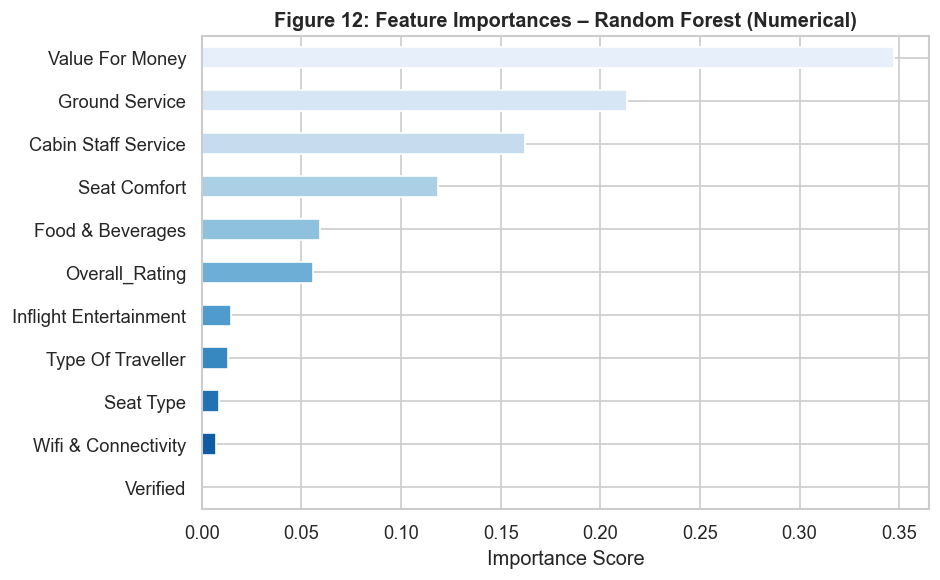

Figure 12 saved.


In [21]:
# ── Figure 12: Feature Importance – Random Forest ────────────────────────────
feat_imp = pd.Series(rf_best.feature_importances_, index=NUM_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color=sns.color_palette('Blues_r', len(feat_imp)))
ax.set_xlabel('Importance Score')
ax.set_title('Figure 12: Feature Importances – Random Forest (Numerical)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_feature_importance_rf.png', bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

In [22]:
# ── Robustness / Stress Test – Temporal Split ─────────────────────────────────
def temporal_robustness_test(df: pd.DataFrame, X: pd.DataFrame, y: pd.Series,
                              model, model_name: str):
    """
    Train on earlier reviews (pre-2020), test on later reviews (2020+).
    Assesses temporal stability of the model.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataframe with 'Date Flown' column.
    X : pd.DataFrame
    y : pd.Series
    model : fitted sklearn estimator
    model_name : str

    Returns
    -------
    dict
        Temporal test metrics.
    """
    # Parse year from 'Date Flown'
    df = df.copy()
    df['year'] = df['Date Flown'].str.extract(r'(\d{4})')[0].astype(float)

    mask_early = df['year'] < 2020
    mask_late  = df['year'] >= 2020

    if mask_early.sum() < 100 or mask_late.sum() < 50:
        print("Insufficient data for temporal split.")
        return None

    X_early, y_early = X[mask_early], y[mask_early]
    X_late,  y_late  = X[mask_late],  y[mask_late]

    model_clone = type(model)(**model.get_params())
    model_clone.fit(X_early, y_early)
    y_pred_late = model_clone.predict(X_late)

    acc = accuracy_score(y_late, y_pred_late)
    f1  = f1_score(y_late, y_pred_late, zero_division=0)

    print(f"\n{'='*55}")
    print(f" Temporal Stress Test – {model_name}")
    print(f" Train: pre-2020 (n={mask_early.sum():,}) → Test: 2020+ (n={mask_late.sum():,})")
    print(f"{'='*55}")
    print(f" Accuracy : {acc:.4f}")
    print(f" F1-Score : {f1:.4f}")
    return {'acc': acc, 'f1': f1}


temporal_rf = temporal_robustness_test(df, X_num, y, rf_best, 'Random Forest')
temporal_gb = temporal_robustness_test(df, X_num, y, gb_best, 'Gradient Boosting')


 Temporal Stress Test – Random Forest
 Train: pre-2020 (n=1,495) → Test: 2020+ (n=4,681)
 Accuracy : 0.9477
 F1-Score : 0.9142

 Temporal Stress Test – Gradient Boosting
 Train: pre-2020 (n=1,495) → Test: 2020+ (n=4,681)
 Accuracy : 0.9442
 F1-Score : 0.9094


---
## Section 4.b – Descriptive & Predictive Analytics (Text Features)

### 4.b.1 Sentiment Analysis – Two Approaches

In [23]:
# ── Approach A: Lexicon-Based Sentiment (simple positive/negative word lists) ─
# A concise domain-specific positive/negative lexicon for airline reviews

POSITIVE_WORDS = {
    'excellent', 'good', 'great', 'amazing', 'comfortable', 'helpful',
    'friendly', 'efficient', 'clean', 'smooth', 'pleasant', 'lovely',
    'professional', 'polite', 'courteous', 'delicious', 'punctual',
    'fantastic', 'superb', 'outstanding', 'wonderful', 'best', 'satisfied',
    'enjoy', 'happy', 'nice', 'recommend', 'impressed', 'reliable'
}

NEGATIVE_WORDS = {
    'terrible', 'awful', 'horrible', 'bad', 'poor', 'rude', 'dirty',
    'delayed', 'cancelled', 'lost', 'broken', 'cold', 'disgusting',
    'uncomfortable', 'cramped', 'disappointing', 'worst', 'horrible',
    'overpriced', 'unprofessional', 'arrogant', 'useless', 'nightmare',
    'refused', 'ignorant', 'unacceptable', 'chaotic', 'misleading'
}


def lexicon_sentiment_score(text: str) -> float:
    """
    Compute a simple lexicon-based sentiment score.

    Score = (positive_tokens - negative_tokens) / (total_tokens + 1)

    Parameters
    ----------
    text : str
        Preprocessed review text.

    Returns
    -------
    float
        Sentiment score in range (-1, 1).
    """
    tokens = set(text.split())
    pos_count = len(tokens & POSITIVE_WORDS)
    neg_count = len(tokens & NEGATIVE_WORDS)
    total     = len(tokens) + 1  # avoid division by zero
    return (pos_count - neg_count) / total


df['sentiment_lexicon'] = df['review_clean'].apply(lexicon_sentiment_score)
print("Lexicon sentiment stats:")
print(df['sentiment_lexicon'].describe().round(4))

Lexicon sentiment stats:
count    6178.0000
mean        0.0043
std         0.0589
min        -0.2941
25%        -0.0278
50%         0.0000
75%         0.0267
max         0.4615
Name: sentiment_lexicon, dtype: float64


In [24]:
# ── Approach B: TF-IDF Polarity Proxy ─────────────────────────────────────────
# Using TF-IDF similarity to curated positive/negative seed sentences
# as a lightweight LLM-free alternative to full transformer sentiment.

def tfidf_polarity_proxy(corpus: pd.Series) -> np.ndarray:
    """
    Approximate sentiment polarity using cosine similarity of TF-IDF vectors
    against anchor positive and negative documents.

    This approach treats sentiment as a directional signal in TF-IDF space
    and serves as a scalable lexicon-agnostic alternative.

    Parameters
    ----------
    corpus : pd.Series
        Cleaned review text.

    Returns
    -------
    np.ndarray
        Polarity score for each review.
    """
    anchor_pos = ('excellent service comfortable seats friendly staff '
                  'professional crew wonderful experience recommend great')
    anchor_neg = ('terrible service rude staff dirty uncomfortable delayed '
                  'cancelled disgusting worst nightmare overpriced disappointed')

    # Fit TF-IDF on full corpus + anchors
    all_texts = list(corpus) + [anchor_pos, anchor_neg]
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    tfidf_mat  = vectorizer.fit_transform(all_texts)

    review_mat  = tfidf_mat[:-2]
    pos_vec     = tfidf_mat[-2]
    neg_vec     = tfidf_mat[-1]

    from sklearn.metrics.pairwise import cosine_similarity
    pos_sim = cosine_similarity(review_mat, pos_vec).ravel()
    neg_sim = cosine_similarity(review_mat, neg_vec).ravel()

    return pos_sim - neg_sim  # positive = similar to positive anchor


df['sentiment_tfidf'] = tfidf_polarity_proxy(df['review_clean'])
print("TF-IDF polarity stats:")
print(df['sentiment_tfidf'].describe().round(4))

# Correlation between the two sentiment approaches
corr_sentiments = df[['sentiment_lexicon', 'sentiment_tfidf', 'Recommended']].corr()
print("\nSentiment correlation matrix:")
print(corr_sentiments.round(3))

TF-IDF polarity stats:
count    6178.0000
mean        0.0073
std         0.0392
min        -0.2498
25%        -0.0118
50%         0.0006
75%         0.0212
max         0.2773
Name: sentiment_tfidf, dtype: float64

Sentiment correlation matrix:
                   sentiment_lexicon  sentiment_tfidf  Recommended
sentiment_lexicon              1.000            0.697        0.664
sentiment_tfidf                0.697            1.000        0.545
Recommended                    0.664            0.545        1.000


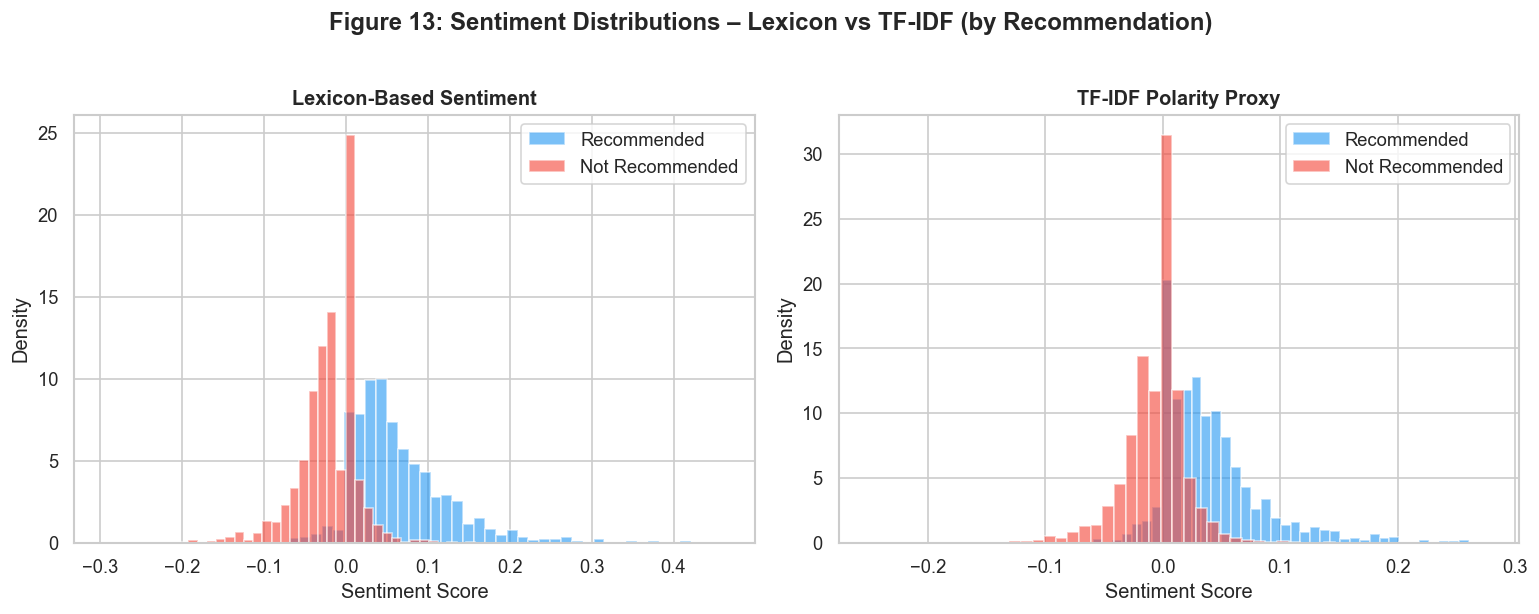

Figure 13 saved.


In [25]:
# ── Figure 13: Sentiment score distributions by recommendation class ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['sentiment_lexicon', 'sentiment_tfidf'],
    ['Lexicon-Based Sentiment', 'TF-IDF Polarity Proxy']
):
    for rec, color, label in [(1, YES_COLOR, 'Recommended'), (0, NO_COLOR, 'Not Recommended')]:
        ax.hist(df.loc[df['Recommended'] == rec, col], bins=40,
                alpha=0.6, color=color, density=True, label=label)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Figure 13: Sentiment Distributions – Lexicon vs TF-IDF (by Recommendation)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_13_sentiment_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

Contradictory reviews (high sentiment + low rating): 404
Recommendation rate among contradictory reviews: 77.0%


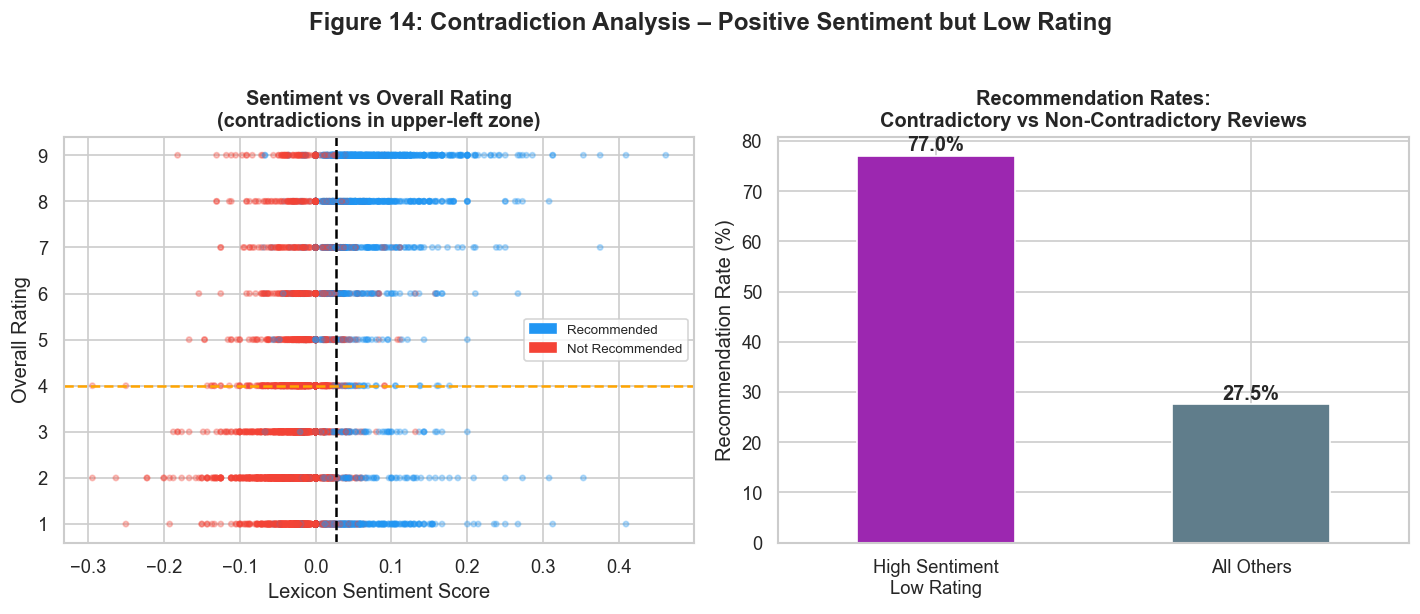

Figure 14 saved.


In [26]:
# ── Figure 14: Contradiction analysis – Positive sentiment but low rating ─────
# High sentiment (top quartile) but low Overall_Rating (below 5)
q75_lex = df['sentiment_lexicon'].quantile(0.75)
contradictory_mask = (df['sentiment_lexicon'] >= q75_lex) & (df['Overall_Rating'] <= 4)
contradiction_df = df[contradictory_mask]

print(f"Contradictory reviews (high sentiment + low rating): {contradictory_mask.sum()}")
print(f"Recommendation rate among contradictory reviews: "
      f"{contradiction_df['Recommended'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: sentiment vs Overall_Rating
axes[0].scatter(df['sentiment_lexicon'], df['Overall_Rating'],
                c=df['Recommended'].map({1: YES_COLOR, 0: NO_COLOR}),
                alpha=0.3, s=10)
axes[0].axvline(q75_lex, color='black', linestyle='--', linewidth=1.5)
axes[0].axhline(4, color='orange', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Lexicon Sentiment Score')
axes[0].set_ylabel('Overall Rating')
axes[0].set_title('Sentiment vs Overall Rating\n(contradictions in upper-left zone)',
                   fontweight='bold')
yes_patch = mpatches.Patch(color=YES_COLOR, label='Recommended')
no_patch  = mpatches.Patch(color=NO_COLOR,  label='Not Recommended')
axes[0].legend(handles=[yes_patch, no_patch], fontsize=8)

# Recommendation rate among contradictory vs normal
groups = pd.Series({
    'High Sentiment\nLow Rating': contradiction_df['Recommended'].mean() * 100,
    'All Others': df[~contradictory_mask]['Recommended'].mean() * 100
})
groups.plot(kind='bar', ax=axes[1], color=['#9C27B0', '#607D8B'], rot=0)
axes[1].set_ylabel('Recommendation Rate (%)')
axes[1].set_title('Recommendation Rates:\nContradictory vs Non-Contradictory Reviews',
                   fontweight='bold')
for i, v in enumerate(groups):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Figure 14: Contradiction Analysis – Positive Sentiment but Low Rating',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_14_contradiction_analysis.png', bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

In [27]:
# ── Manual review of 10 ambiguous/misclassified cases ────────────────────────
# Select reviews near sentiment score boundary (near 0) with recommendation mismatch

borderline = df[
    (df['sentiment_lexicon'].abs() < 0.02) &
    (df['review_clean'].str.len() > 50)
].copy()

print(f"Borderline reviews (near-zero lexicon sentiment): {len(borderline)}")
print("\n--- Sample Ambiguous Reviews for Manual Analysis ---")
sample_ambiguous = borderline.sample(min(10, len(borderline)), random_state=RANDOM_SEED)

for i, (idx, row) in enumerate(sample_ambiguous.iterrows(), 1):
    rec_label = 'YES' if row['Recommended'] == 1 else 'NO'
    print(f"\n[Review {i}] Recommended={rec_label} | "
          f"Lex_Sent={row['sentiment_lexicon']:.4f} | "
          f"Overall={row['Overall_Rating']:.0f}")
    raw_review = row['Review'][:300] if isinstance(row['Review'], str) else ''
    print(f"  Review (raw): {raw_review}...")

Borderline reviews (near-zero lexicon sentiment): 2406

--- Sample Ambiguous Reviews for Manual Analysis ---

[Review 1] Recommended=NO | Lex_Sent=-0.0156 | Overall=3
  Review (raw): ✅Trip Verified|  Huatulco to Oaxaca. Booked our flights 6 months in advance and a month later they cancelled our flight. We had booked a return trip and one leg was cancelled but they insisted on cancelling both legs and that I buy a new ticket on the one leg that we could use. The company promised ...

[Review 2] Recommended=NO | Lex_Sent=0.0000 | Overall=5
  Review (raw): ✅Trip Verified| It would be bad citizenship if I don't write about my experience with Turkish airline. If you plan to book a trip in which ones possible airline option is Turkish, please make sure you have adjusted expectations. I travel often from the US to middle east and tried different airlines....

[Review 3] Recommended=YES | Lex_Sent=0.0108 | Overall=9
  Review (raw): ✅Trip Verified|   NRT to TPE with JX801 on 2 AUG and back with


 Random Forest (Text – TF-IDF)
Accuracy : 0.9644
F1-Score : 0.9418
ROC-AUC  : 0.9934

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.97      0.98      0.97       856
 Recommended       0.95      0.94      0.94       380

    accuracy                           0.96      1236
   macro avg       0.96      0.96      0.96      1236
weighted avg       0.96      0.96      0.96      1236



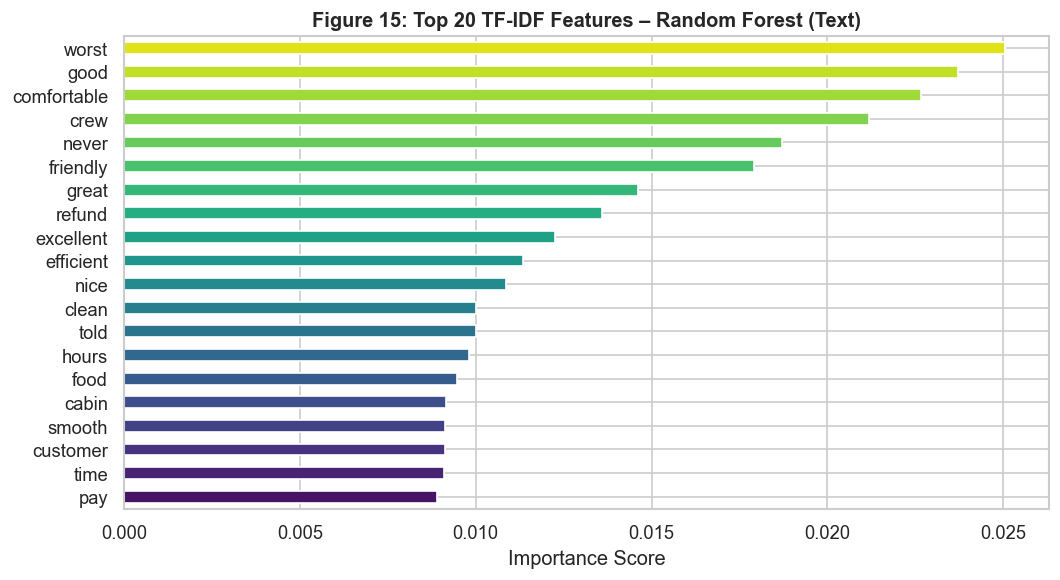

Figure 15 saved.


In [28]:
# ── Figure 15: Text feature importance (TF-IDF + RF) ─────────────────────────
# Train a simple RF on TF-IDF features to extract which words predict recommendation

tfidf_vec = TfidfVectorizer(max_features=2000, ngram_range=(1, 2),
                             min_df=5, max_df=0.95)
X_text_full = tfidf_vec.fit_transform(df['review_clean'])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text_full, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

rf_text = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=RANDOM_SEED, n_jobs=-1)
rf_text.fit(X_train_t, y_train_t)
results_rf_text = train_and_evaluate_model(rf_text, X_train_t, X_test_t,
                                            y_train_t, y_test_t,
                                            'Random Forest (Text – TF-IDF)')

# Top 20 words by importance
feature_names = tfidf_vec.get_feature_names_out()
top_idx = rf_text.feature_importances_.argsort()[-20:][::-1]
top_words = pd.Series(rf_text.feature_importances_[top_idx],
                       index=feature_names[top_idx])

fig, ax = plt.subplots(figsize=(9, 5))
top_words[::-1].plot(kind='barh', ax=ax,
                     color=sns.color_palette('viridis', 20))
ax.set_xlabel('Importance Score')
ax.set_title('Figure 15: Top 20 TF-IDF Features – Random Forest (Text)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_15_tfidf_feature_importance.png', bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

In [29]:
# ── GB on Text features ───────────────────────────────────────────────────────
gb_text = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      random_state=RANDOM_SEED)
gb_text.fit(X_train_t, y_train_t)
results_gb_text = train_and_evaluate_model(gb_text, X_train_t, X_test_t,
                                            y_train_t, y_test_t,
                                            'Gradient Boosting (Text – TF-IDF)')


 Gradient Boosting (Text – TF-IDF)
Accuracy : 0.9134
F1-Score : 0.8482
ROC-AUC  : 0.9756

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.91      0.97      0.94       856
 Recommended       0.92      0.79      0.85       380

    accuracy                           0.91      1236
   macro avg       0.92      0.88      0.89      1236
weighted avg       0.91      0.91      0.91      1236



---
## Section 4.c – Combined Numerical + Text Features

In [30]:
from scipy.sparse import hstack, csr_matrix

# ── Feature Integration Strategy 1: Simple concatenation of TF-IDF + numeric ─
# Convert numerical features to sparse and stack horizontally with TF-IDF

X_num_sparse = csr_matrix(X_num.values.astype(float))
X_combined   = hstack([X_text_full, X_num_sparse])

print("Combined feature matrix shape:", X_combined.shape)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# ── RF on Combined ───────────────────────────────────────────────────────────
rf_combined = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=RANDOM_SEED, n_jobs=-1)
rf_combined.fit(X_train_c, y_train_c)
results_rf_combined = train_and_evaluate_model(rf_combined, X_train_c, X_test_c,
                                                y_train_c, y_test_c,
                                                'Random Forest (Combined)')

# ── GB on Combined ───────────────────────────────────────────────────────────
gb_combined = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                          random_state=RANDOM_SEED)
gb_combined.fit(X_train_c, y_train_c)
results_gb_combined = train_and_evaluate_model(gb_combined, X_train_c, X_test_c,
                                                y_train_c, y_test_c,
                                                'Gradient Boosting (Combined)')

Combined feature matrix shape: (6178, 2011)

 Random Forest (Combined)
Accuracy : 0.9838
F1-Score : 0.9737
ROC-AUC  : 0.9986

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.99      0.99      0.99       856
 Recommended       0.97      0.97      0.97       380

    accuracy                           0.98      1236
   macro avg       0.98      0.98      0.98      1236
weighted avg       0.98      0.98      0.98      1236


 Gradient Boosting (Combined)
Accuracy : 0.9660
F1-Score : 0.9443
ROC-AUC  : 0.9946

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.97      0.98      0.98       856
 Recommended       0.95      0.94      0.94       380

    accuracy                           0.97      1236
   macro avg       0.96      0.96      0.96      1236
weighted avg       0.97      0.97      0.97      1236



In [31]:
# ── Feature Integration Strategy 2: Sentiment scores + numerics ──────────────
# Use extracted scalar sentiment scores (lexicon + tfidf) as additional features

X_enriched = X_num.copy()
X_enriched['sentiment_lexicon'] = df['sentiment_lexicon'].values
X_enriched['sentiment_tfidf']   = df['sentiment_tfidf'].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enriched, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

rf_enriched = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=RANDOM_SEED, n_jobs=-1)
rf_enriched.fit(X_train_e, y_train_e)
results_rf_enriched = train_and_evaluate_model(
    rf_enriched, X_train_e, X_test_e, y_train_e, y_test_e,
    'Random Forest (Num + Sentiment Scores)'
)


 Random Forest (Num + Sentiment Scores)
Accuracy : 0.9782
F1-Score : 0.9642
ROC-AUC  : 0.9953

Classification Report:
              precision    recall  f1-score   support

    Not Rec.       0.98      0.99      0.98       856
 Recommended       0.97      0.96      0.96       380

    accuracy                           0.98      1236
   macro avg       0.98      0.97      0.97      1236
weighted avg       0.98      0.98      0.98      1236



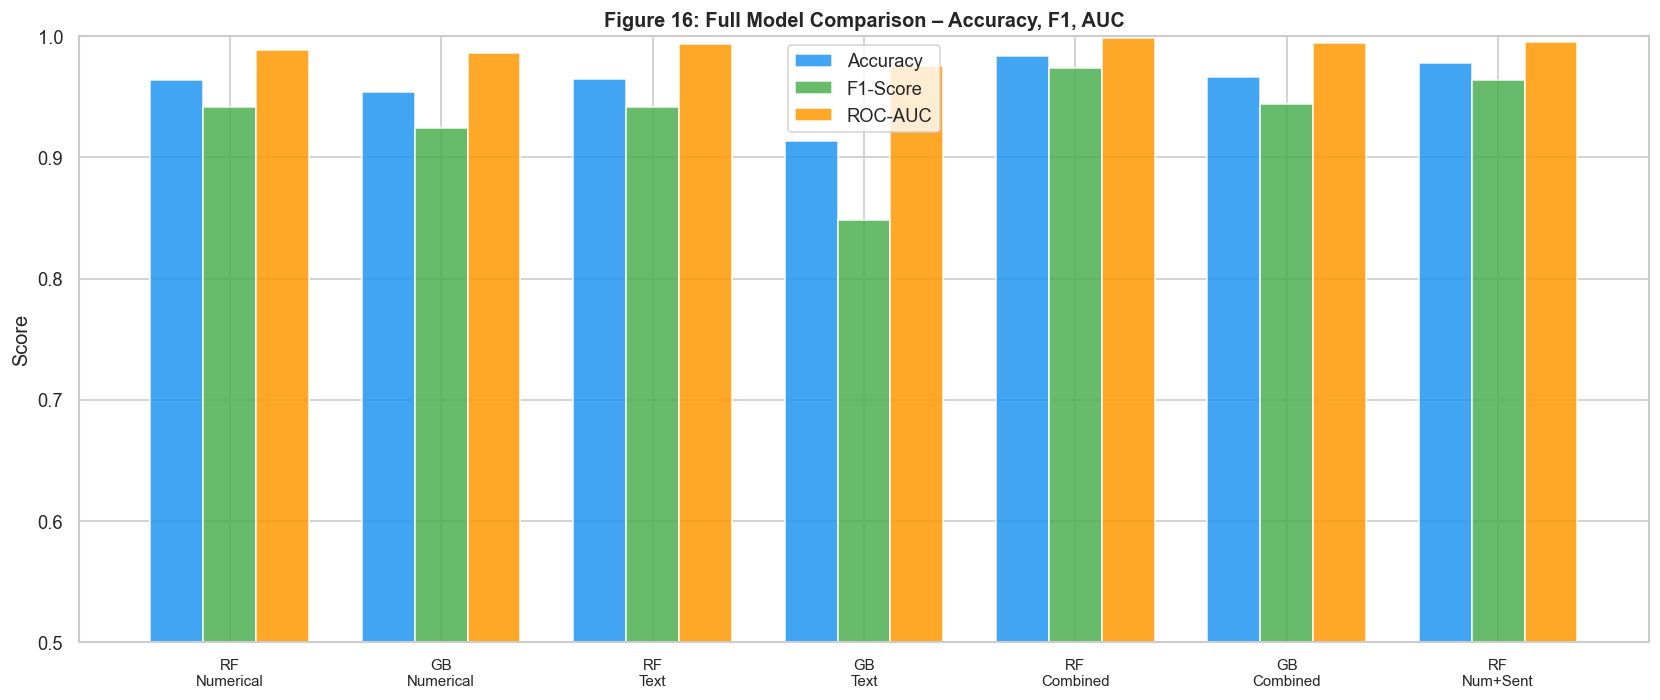

Figure 16 saved.


In [32]:
# ── Figure 16: Full model comparison bar chart ────────────────────────────────
all_results = {
    'RF\nNumerical':    (results_rf_num['acc'],     results_rf_num['f1'],     results_rf_num['auc']),
    'GB\nNumerical':    (results_gb_num['acc'],     results_gb_num['f1'],     results_gb_num['auc']),
    'RF\nText':         (results_rf_text['acc'],    results_rf_text['f1'],    results_rf_text['auc']),
    'GB\nText':         (results_gb_text['acc'],    results_gb_text['f1'],    results_gb_text['auc']),
    'RF\nCombined':     (results_rf_combined['acc'],results_rf_combined['f1'],results_rf_combined['auc']),
    'GB\nCombined':     (results_gb_combined['acc'],results_gb_combined['f1'],results_gb_combined['auc']),
    'RF\nNum+Sent':     (results_rf_enriched['acc'],results_rf_enriched['f1'],results_rf_enriched['auc']),
}

labels  = list(all_results.keys())
accs    = [v[0] for v in all_results.values()]
f1s     = [v[1] for v in all_results.values()]
aucs    = [v[2] for v in all_results.values()]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, accs, width, label='Accuracy',  color='#2196F3', alpha=0.85)
ax.bar(x,          f1s,  width, label='F1-Score',  color='#4CAF50', alpha=0.85)
ax.bar(x + width,  aucs, width, label='ROC-AUC',   color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Figure 16: Full Model Comparison – Accuracy, F1, AUC',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_16_model_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 16 saved.")

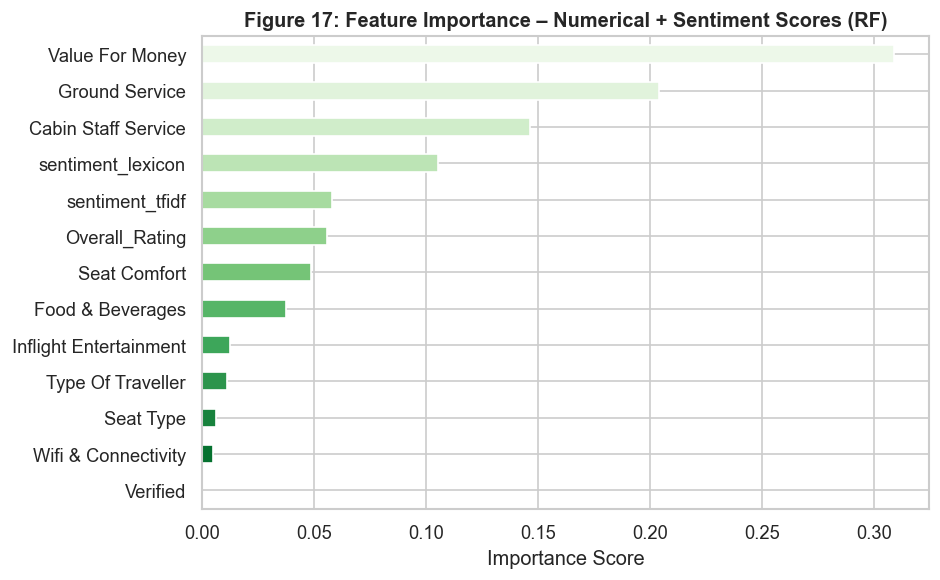

Figure 17 saved.


In [33]:
# ── Combined Feature Importance (Strategy 2 – enriched numeric) ───────────────
enriched_feat_names = list(X_enriched.columns)
enriched_imp = pd.Series(
    rf_enriched.feature_importances_,
    index=enriched_feat_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
enriched_imp.plot(kind='barh', ax=ax, color=sns.color_palette('Greens_r', len(enriched_imp)))
ax.set_xlabel('Importance Score')
ax.set_title('Figure 17: Feature Importance – Numerical + Sentiment Scores (RF)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_17_combined_feature_importance.png', bbox_inches='tight')
plt.show()
print("Figure 17 saved.")

In [34]:
# ── Failure Analysis: Where combined model underperforms ─────────────────────
def failure_analysis(y_true: np.ndarray, y_pred: np.ndarray,
                     df_subset: pd.DataFrame, model_name: str):
    """
    Identify and analyse misclassified instances.

    Parameters
    ----------
    y_true : array
    y_pred : array
    df_subset : pd.DataFrame
        Test subset with original features.
    model_name : str
    """
    errors = y_true != y_pred
    n_errors = errors.sum()
    print(f"\n=== Failure Analysis – {model_name} ===")
    print(f"Total misclassifications: {n_errors:,} / {len(y_true):,} "
          f"({n_errors/len(y_true)*100:.1f}%)")

    # Type of errors
    false_pos = ((y_pred == 1) & (y_true == 0)).sum()  # predicted yes, actually no
    false_neg = ((y_pred == 0) & (y_true == 1)).sum()  # predicted no, actually yes
    print(f"  False Positives (predicted Rec but wasn't): {false_pos}")
    print(f"  False Negatives (missed a Rec): {false_neg}")

    return errors


# Use test indices for enriched model
errors_combined = failure_analysis(
    y_test_e.values, results_rf_enriched['y_pred'],
    df.iloc[y_test_e.index] if hasattr(y_test_e, 'index') else df.iloc[:len(y_test_e)],
    'RF – Num + Sentiment'
)


=== Failure Analysis – RF – Num + Sentiment ===
Total misclassifications: 27 / 1,236 (2.2%)
  False Positives (predicted Rec but wasn't): 11
  False Negatives (missed a Rec): 16


---
## Section 5 – Results Summary Table

In [35]:
results_summary = pd.DataFrame([
    {'Model': 'Random Forest',       'Feature Set': 'Numerical',          **{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_rf_num['acc'],     results_rf_num['f1'],     results_rf_num['auc']])}},
    {'Model': 'Gradient Boosting',   'Feature Set': 'Numerical',          **{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_gb_num['acc'],     results_gb_num['f1'],     results_gb_num['auc']])}},
    {'Model': 'Random Forest',       'Feature Set': 'Text (TF-IDF)',      **{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_rf_text['acc'],    results_rf_text['f1'],    results_rf_text['auc']])}},
    {'Model': 'Gradient Boosting',   'Feature Set': 'Text (TF-IDF)',      **{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_gb_text['acc'],    results_gb_text['f1'],    results_gb_text['auc']])}},
    {'Model': 'Random Forest',       'Feature Set': 'Combined (TF-IDF+Num)',**{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_rf_combined['acc'],results_rf_combined['f1'],results_rf_combined['auc']])}},
    {'Model': 'Gradient Boosting',   'Feature Set': 'Combined (TF-IDF+Num)',**{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_gb_combined['acc'],results_gb_combined['f1'],results_gb_combined['auc']])}},
    {'Model': 'Random Forest',       'Feature Set': 'Num + Sent Scores',  **{k: round(v, 4) for k, v in zip(['Accuracy','F1','AUC'], [results_rf_enriched['acc'],results_rf_enriched['f1'],results_rf_enriched['auc']])}},
])

print("=" * 80)
print(" COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_summary.to_string(index=False))
print("=" * 80)

 COMPREHENSIVE MODEL PERFORMANCE SUMMARY
            Model           Feature Set  Accuracy     F1    AUC
    Random Forest             Numerical    0.9636 0.9416 0.9889
Gradient Boosting             Numerical    0.9539 0.9245 0.9859
    Random Forest         Text (TF-IDF)    0.9644 0.9418 0.9934
Gradient Boosting         Text (TF-IDF)    0.9134 0.8482 0.9756
    Random Forest Combined (TF-IDF+Num)    0.9838 0.9737 0.9986
Gradient Boosting Combined (TF-IDF+Num)    0.9660 0.9443 0.9946
    Random Forest     Num + Sent Scores    0.9782 0.9642 0.9953


In [36]:
print("\n✅ All analyses complete. Figures saved as PNG files in the working directory.")
print("Figures generated:")
import glob
for f in sorted(glob.glob('fig_*.png')):
    print(f"  {f}")


✅ All analyses complete. Figures saved as PNG files in the working directory.
Figures generated:
  fig_01_missing_data_precleaning.png
  fig_02_pre_post_Overall_Rating.png
  fig_03_top_tokens_by_class.png
  fig_04_rating_distributions.png
  fig_05_correlation_heatmap.png
  fig_06_mean_ratings_comparison.png
  fig_07_radar_management_dashboard.png
  fig_08_seattype_recommendation.png
  fig_09_traveller_recommendation_rate.png
  fig_10_confusion_matrices_num.png
  fig_11_roc_curves_num.png
  fig_12_feature_importance_rf.png
  fig_13_sentiment_comparison.png
  fig_14_contradiction_analysis.png
  fig_15_tfidf_feature_importance.png
  fig_16_model_comparison.png
  fig_17_combined_feature_importance.png
